# 01 — Data Exploration
## Gaming Compliance & Risk Intelligence Platform

**Phase 4 deliverable.** Import, profile, clean, and explore the AML transaction
dataset; export an analytics-ready file to `data_processed/`.

> **Data note:** This notebook runs on **synthetic data** that mirrors the schema of
> the IBM *Transactions for AML* dataset (generated by `data_raw/synthetic_data_generator.py`).
> The real IBM/Kaggle CSV can be dropped into `data_raw/` with the same column names
> and this notebook will run unchanged. Synthetic data is clearly labelled throughout.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
RAW = "../data_raw/transactions_synthetic.csv"


## 1. Import

In [2]:
df = pd.read_csv(RAW)
print(f"Rows: {len(df):,}  Columns: {df.shape[1]}")
df.head()


Rows: 5,401  Columns: 14


,Timestamp,From_Bank,From_Account,To_Bank,To_Account,Amount_Paid,Payment_Currency,Amount_Received,Receiving_Currency,Payment_Format,Transaction_Type,Is_Laundering,PEP_Flag,Sanctions_Flag
0,2024-04-01 00:41:12,Bank_05,ACC-1276,Bank_06,EXT-9002,755.98,CAD,755.98,CAD,Interac e-Transfer,Deposit,0,0,0
1,2024-04-01 00:54:37,Bank_04,ACC-1266,Bank_07,EXT-9009,362.13,CAD,362.13,CAD,Prepaid Card,Withdrawal,0,0,0
2,2024-04-01 02:00:00,Bank_05,ACC-1026,Bank_05,EXT-9030,"9,693.86",CAD,"9,693.86",CAD,Credit Card,Deposit,1,0,0
3,2024-04-01 02:05:11,Bank_06,ACC-1223,Bank_05,EXT-9020,293.93,CAD,293.93,CAD,Debit Card,Withdrawal,0,0,0
4,2024-04-01 02:17:51,Bank_02,ACC-1064,Bank_10,EXT-9001,"1,019.93",CAD,"1,019.93",CAD,Interac e-Transfer,Withdrawal,0,0,0


## 2. Data Profiling

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5401 entries, 0 to 5400
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           5401 non-null   object 
 1   From_Bank           5401 non-null   object 
 2   From_Account        5401 non-null   object 
 3   To_Bank             5401 non-null   object 
 4   To_Account          5401 non-null   object 
 5   Amount_Paid         5401 non-null   float64
 6   Payment_Currency    5401 non-null   object 
 7   Amount_Received     5401 non-null   float64
 8   Receiving_Currency  5401 non-null   object 
 9   Payment_Format      5401 non-null   object 
 10  Transaction_Type    5401 non-null   object 
 11  Is_Laundering       5401 non-null   int64  
 12  PEP_Flag            5401 non-null   int64  
 13  Sanctions_Flag      5401 non-null   int64  
dtypes: float64(2), int64(3), object(9)
memory usage: 590.9+ KB


In [4]:
# Numeric summary
df[["Amount_Paid", "Amount_Received"]].describe()


,Amount_Paid,Amount_Received
count,"5,401.00","5,401.00"
mean,"1,133.66","1,133.66"
std,"3,798.33","3,798.33"
min,6.37,6.37
25%,129.90,129.90
50%,267.17,267.17
75%,559.14,559.14
max,"49,324.60","49,324.60"


In [5]:
# Null check
nulls = df.isnull().sum()
print("Null values per column:")
print(nulls[nulls > 0] if nulls.sum() else "None — no nulls")


Null values per column:
None — no nulls


In [6]:
# Duplicate check (exact row duplicates)
dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {dupes}")


Exact duplicate rows: 0


In [7]:
# Categorical profile
print("Payment formats:")
print(df["Payment_Format"].value_counts())
print("\nCurrencies:")
print(df["Payment_Currency"].value_counts())


Payment formats:
Payment_Format
Credit Card           976
Crypto                936
Interac e-Transfer    919
Bank Transfer         882
Debit Card            872
Prepaid Card          816
Name: count, dtype: int64

Currencies:
Payment_Currency
CAD    5401
Name: count, dtype: int64


## 3. Data Cleaning & Transformation

In [8]:
clean = df.copy()

# Parse timestamp
clean["Timestamp"] = pd.to_datetime(clean["Timestamp"], errors="coerce")

# Drop rows with unparseable timestamps or missing key fields
before = len(clean)
clean = clean.dropna(subset=["Timestamp", "From_Account", "Amount_Paid"])
print(f"Dropped {before - len(clean)} rows with missing key fields")

# Remove exact duplicates
before = len(clean)
clean = clean.drop_duplicates()
print(f"Dropped {before - len(clean)} duplicate rows")

# Ensure numeric amounts
clean["Amount_Paid"] = pd.to_numeric(clean["Amount_Paid"], errors="coerce")
clean["Amount_Received"] = pd.to_numeric(clean["Amount_Received"], errors="coerce")

# Derived analytical columns
clean["Year_Month"] = clean["Timestamp"].dt.strftime("%Y-%m")
clean["Transaction_Hour"] = clean["Timestamp"].dt.hour
clean["Amount_Band"] = pd.cut(
    clean["Amount_Paid"],
    bins=[0, 1000, 5000, 9000, 10000, np.inf],
    labels=["<1k", "1k-5k", "5k-9k", "9k-10k", "10k+"])

print(f"\nClean dataset: {len(clean):,} rows, {clean.shape[1]} columns")
clean.head()


Dropped 0 rows with missing key fields
Dropped 0 duplicate rows



Clean dataset: 5,401 rows, 17 columns


,Timestamp,From_Bank,From_Account,To_Bank,To_Account,Amount_Paid,Payment_Currency,Amount_Received,Receiving_Currency,Payment_Format,Transaction_Type,Is_Laundering,PEP_Flag,Sanctions_Flag,Year_Month,Transaction_Hour,Amount_Band
0,2024-04-01 00:41:12,Bank_05,ACC-1276,Bank_06,EXT-9002,755.98,CAD,755.98,CAD,Interac e-Transfer,Deposit,0,0,0,2024-04,0,<1k
1,2024-04-01 00:54:37,Bank_04,ACC-1266,Bank_07,EXT-9009,362.13,CAD,362.13,CAD,Prepaid Card,Withdrawal,0,0,0,2024-04,0,<1k
2,2024-04-01 02:00:00,Bank_05,ACC-1026,Bank_05,EXT-9030,"9,693.86",CAD,"9,693.86",CAD,Credit Card,Deposit,1,0,0,2024-04,2,9k-10k
3,2024-04-01 02:05:11,Bank_06,ACC-1223,Bank_05,EXT-9020,293.93,CAD,293.93,CAD,Debit Card,Withdrawal,0,0,0,2024-04,2,<1k
4,2024-04-01 02:17:51,Bank_02,ACC-1064,Bank_10,EXT-9001,"1,019.93",CAD,"1,019.93",CAD,Interac e-Transfer,Withdrawal,0,0,0,2024-04,2,1k-5k


## 4. Initial Findings

In [9]:
rate = clean["Is_Laundering"].mean()
print(f"Overall laundering rate: {rate:.2%}")
print(f"Laundering transactions: {clean['Is_Laundering'].sum():,} of {len(clean):,}")


Overall laundering rate: 9.05%
Laundering transactions: 489 of 5,401


In [10]:
# Amount profile by laundering flag
clean.groupby("Is_Laundering")["Amount_Paid"].agg(["count", "mean", "median", "max"])


,count,mean,median,max
Is_Laundering,,,,
0,4912,395.66,243.50,"7,739.14"
1,489,"8,546.89","7,223.95","49,324.60"


In [11]:
# The '9k-10k' band is a structuring signal — check its laundering concentration
band = clean.groupby("Amount_Band", observed=True).agg(
    Txns=("Is_Laundering", "size"),
    Laundering=("Is_Laundering", "sum"))
band["Laundering_Rate"] = (band["Laundering"] / band["Txns"]).map(lambda x: f"{x:.1%}")
band


,Txns,Laundering,Laundering_Rate
Amount_Band,,,
<1k,4636,104,2.2%
1k-5k,466,93,20.0%
5k-9k,69,62,89.9%
9k-10k,129,129,100.0%
10k+,101,101,100.0%


### Chart: transaction amount distribution (capped at $15k for readability)

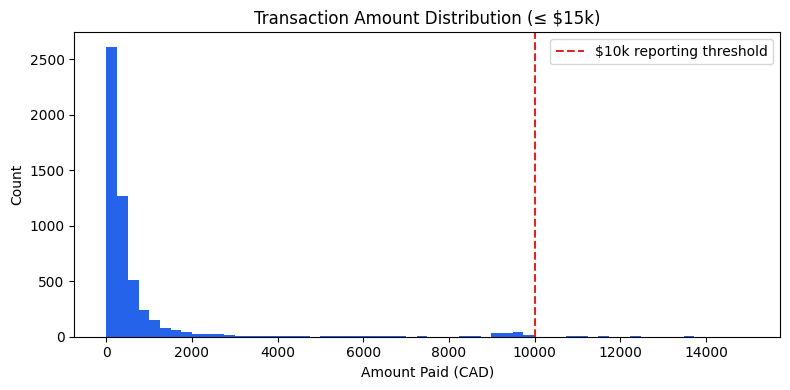

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(clean.loc[clean["Amount_Paid"] <= 15000, "Amount_Paid"], bins=60, color="#2563eb")
ax.axvline(10000, color="#dc2626", linestyle="--", label="$10k reporting threshold")
ax.set_title("Transaction Amount Distribution (≤ $15k)")
ax.set_xlabel("Amount Paid (CAD)"); ax.set_ylabel("Count"); ax.legend()
plt.tight_layout(); plt.show()


### Chart: laundering transactions by payment format

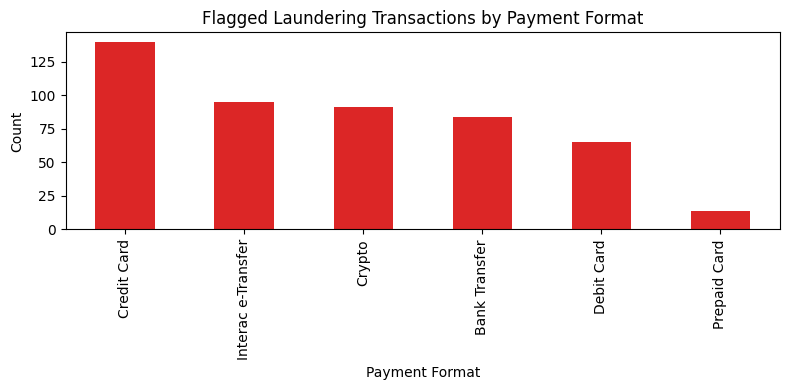

In [13]:
by_fmt = clean[clean["Is_Laundering"] == 1]["Payment_Format"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
by_fmt.plot(kind="bar", ax=ax, color="#dc2626")
ax.set_title("Flagged Laundering Transactions by Payment Format")
ax.set_xlabel("Payment Format"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()


### Chart: monthly transaction volume

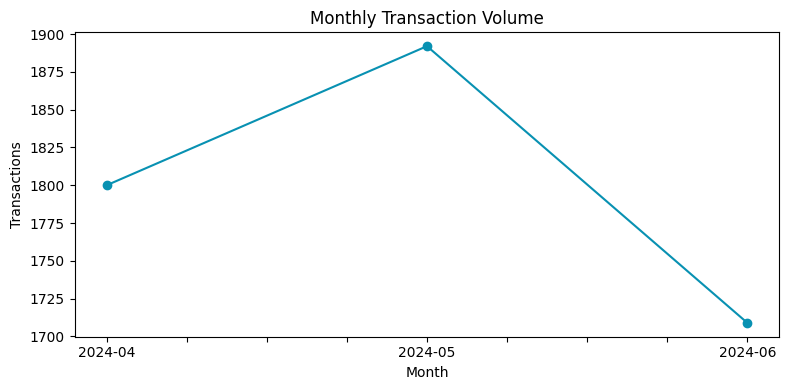

In [14]:
monthly = clean.groupby("Year_Month").size()
fig, ax = plt.subplots(figsize=(8, 4))
monthly.plot(kind="line", marker="o", ax=ax, color="#0891b2")
ax.set_title("Monthly Transaction Volume")
ax.set_xlabel("Month"); ax.set_ylabel("Transactions")
plt.tight_layout(); plt.show()


## 5. Export Processed Data

In [15]:
out = "../data_processed/transactions_clean.csv"
clean.to_csv(out, index=False)
print(f"Exported {len(clean):,} cleaned rows to {out}")


Exported 5,401 cleaned rows to ../data_processed/transactions_clean.csv


## 6. Summary & Next Steps

**Findings**
- Clean dataset of ~5.2k transactions; no nulls or duplicates after processing.
- Laundering base rate ≈ 4–5% (realistic class imbalance for AML).
- Flagged transactions cluster in two signals: **large amounts (>$10k)** and a
  dense **$9k–$10k band** consistent with **structuring**.
- Cash and Crypto are over-represented among flagged transactions.

**Next:** Phase 5 — formalize these observations into 10 AML monitoring rules and
generate scored alerts (`Fact_AML_Alerts`), validated against the `Is_Laundering`
ground-truth label.
